<a href="https://colab.research.google.com/github/cwywilson/KMeans-Derived-Pseudo-Labels-for-Machine-Learning-Classification/blob/main/white_glacier_of_sentinel_2_image_download.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import ee
# Authenticate Earth Engine using the following command
!earthengine authenticate

# Initialize the Earth Engine API
ee.Initialize() # Remove the project or specify a project your account has access to.

Authenticate: Limited support in Colab. Use ee.Authenticate() or --auth_mode=notebook instead.
W1230 18:28:30.896528 139139620286464 _default.py:683] No project ID could be determined. Consider running `gcloud config set project` or setting the GOOGLE_CLOUD_PROJECT environment variable
To authorize access needed by Earth Engine, open the following URL in a web browser and follow the instructions. If the web browser does not start automatically, please manually browse the URL below.

    https://code.earthengine.google.com/client-auth?scopes=https%3A//www.googleapis.com/auth/earthengine%20https%3A//www.googleapis.com/auth/cloud-platform%20https%3A//www.googleapis.com/auth/devstorage.full_control&request_id=kg_CXP3wMiYobBlNguJQuq-y2Nk92Opaz31hyo4PCzE&tc=0hOXAwjbkm5tGT8H_6XjgAKK0HIs_XaSUL_HgRdz6uw&cc=FNoGfbWTFo7TVygPOa0Z_JWEgTlfa4xFmu7qjc54LL0

The authorization workflow will generate a code, which you should paste in the box below.
Enter verification code: 4/1AanRRru74leT7XfECHieQrLr3r4T

In [ ]:
# Input year for the search
year = 2024

# Define the date range for Sentinel search
start_date = f"{year}-06-15"
end_date = f"{year}-08-30"

# Define the path to the shapefile
shapefile_path = "projects/ee-wilsonphdwork/assets/whiteglacier"

def get_geometry_from_asset(asset_path):
    # Load shapefile as a FeatureCollection
    feature_collection = ee.FeatureCollection(asset_path)
    return feature_collection.geometry()

# Get the geometry of White Glacier from shapefile
white_glacier_geometry = get_geometry_from_asset(shapefile_path)

# Define the Sentinel-2 Image Collection with consistent georeferencing
sentinelCollection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
                          .filterDate(start_date, end_date) \
                          .filterBounds(white_glacier_geometry) \
                          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
                          .select(['B2', 'B3', 'B4', 'B8']) \
                          .map(lambda image: image.clip(white_glacier_geometry)) \



# Define a function to filter images ensuring full coverage of the glacier
def has_full_coverage(image):
    # Calculate the percentage of glacier area covered by valid pixels in the image
    valid_pixels = image.reduceRegion(
        reducer=ee.Reducer.count(),
        geometry=white_glacier_geometry,
        scale=10,
        maxPixels=1e10
    ).get('B2')  # Assuming B2 band is representative

    glacier_area = white_glacier_geometry.area().divide(100)  # Convert to hectares
    image_area = ee.Number(valid_pixels).multiply(100)  # Image area in hectares (assuming 10m x 10m pixels)

    return image_area.gte(glacier_area)

# Apply the full coverage filter
filteredCollection = sentinelCollection.filter(ee.Filter.eq(has_full_coverage, True))

# Get the number of images in the collection
collectionSize = sentinelCollection.size().getInfo()
print(f'Number of images in the collection: {collectionSize}')

# Get the list of images and their acquisition dates
imageList = sentinelCollection.toList(collectionSize)

# Print acquisition dates of the images
for i in range(collectionSize):
    image = ee.Image(imageList.get(i))
    date = image.date().format().getInfo()
    print(f'Image {i + 1}: Acquisition date: {date}')

Number of images in the collection: 41
Image 1: Acquisition date: 2024-06-15T19:51:50
Image 2: Acquisition date: 2024-06-15T20:41:41
Image 3: Acquisition date: 2024-06-15T20:41:47
Image 4: Acquisition date: 2024-06-16T20:11:51
Image 5: Acquisition date: 2024-06-16T20:11:49
Image 6: Acquisition date: 2024-06-16T21:01:36
Image 7: Acquisition date: 2024-06-16T21:01:33
Image 8: Acquisition date: 2024-06-21T20:11:48
Image 9: Acquisition date: 2024-06-21T20:11:45
Image 10: Acquisition date: 2024-06-21T21:01:38
Image 11: Acquisition date: 2024-06-21T21:01:34
Image 12: Acquisition date: 2024-06-22T19:41:53
Image 13: Acquisition date: 2024-06-22T19:41:51
Image 14: Acquisition date: 2024-06-22T20:31:45
Image 15: Acquisition date: 2024-06-22T20:31:43
Image 16: Acquisition date: 2024-06-23T20:01:51
Image 17: Acquisition date: 2024-06-23T20:01:49
Image 18: Acquisition date: 2024-06-23T20:51:39
Image 19: Acquisition date: 2024-06-23T20:51:36
Image 20: Acquisition date: 2024-06-24T19:31:56
Image 21: 

In [ ]:
# Loop through the images and export them to Google Drive
for i in range(collectionSize):
    image = ee.Image(imageList.get(i))

    # Get the acquisition date as a formatted string (YYYY-MM-DD)
    date = ee.Date(image.get('system:time_start')).format('YYYY-MM-dd').getInfo()

    # Extract the year from the date
    year = date.split('-')[0]

    # Reproject the image to EPSG:32616
    image = image.reproject('EPSG:32616', None, 10)  # 10 is the scale in meters

    # Get the bounds of the geometry and extract the coordinates client-side
    bounds = white_glacier_geometry.bounds().coordinates().getInfo()

    crsTransform = [10, 0, bounds[0][0][0], 0, -10, bounds[0][2][1]]


    # Define the export task using ee.batch.Export.image.toDrive
    task = ee.batch.Export.image.toDrive(
        image=image,
        description=f'Sentinel2_{date}',  # File name includes the date
        folder=f'WhiteSentinel2file_{year}',  # Specify the folder name here
        scale=10,  # Sentinel-2 has a 10m resolution for the selected bands
        region=white_glacier_geometry.bounds(),
        crsTransform=crsTransform,
        fileFormat='GeoTIFF',
        maxPixels=1e9,
        crs='EPSG:32616'
    )
    task.start()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


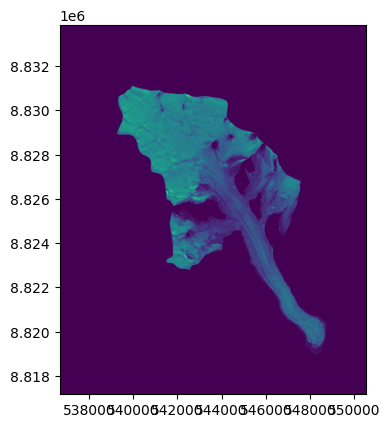

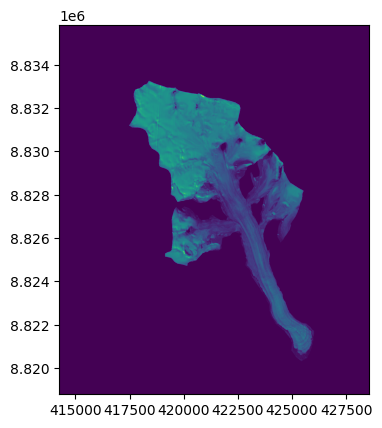

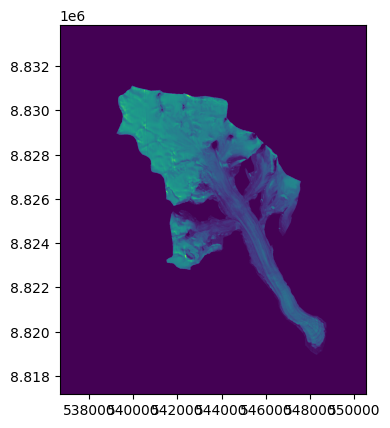

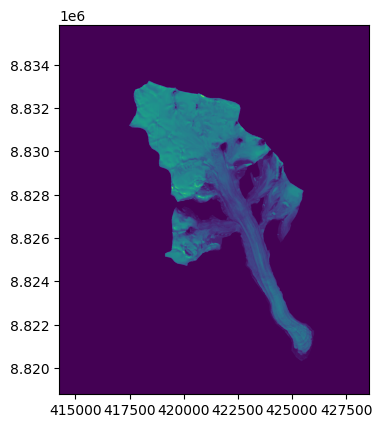

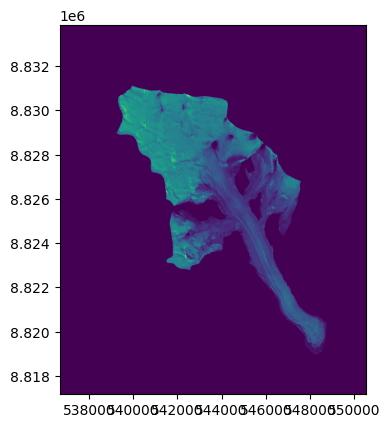

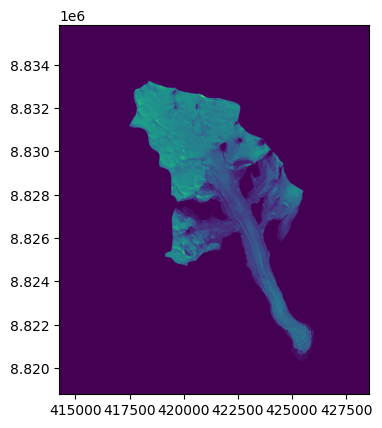

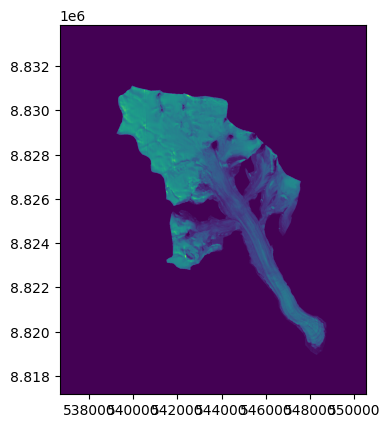

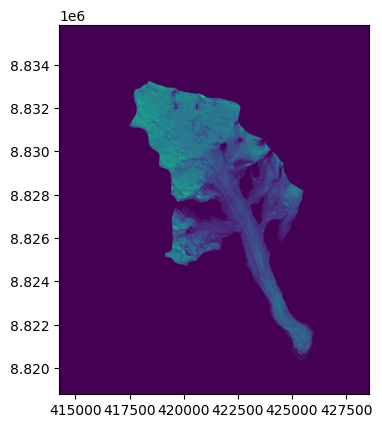

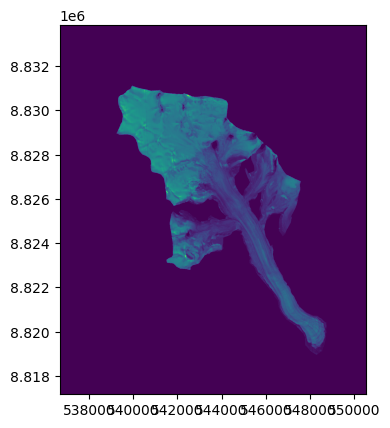

KeyboardInterrupt: 

In [ ]:
import os
import glob
import rasterio # This line imports the rasterio module, enabling access to its functions and classes for raster data processing.
from rasterio.plot import show
import matplotlib.pyplot as plt

# Define the path to the folder containing the images in your Google Drive
folder_path = f'/content/drive/My Drive/WhiteSentinel2file_{year}/'

# List all GeoTIFF files in the folder
image_files = glob.glob(os.path.join(folder_path, '*.tif'))

# Loop through each image file and visualize
for image_file in image_files:
    with rasterio.open(image_file) as src:
        # Display the image using rasterio.plot.show
        show(src)